# 13. Portfolio Optimization with Reinforcement Learning

This tutorial provides a step-by-step guide for implementing a Unit Operator with a Portfolio Strategy in the ASSUME framework. By the end of this guide, you will be familiar with the process of creating and integrating a Portfolio within the electricity market simulation environment provided by ASSUME.


**We will cover the following topics:**

1. [Introduction to Unit Operators and Portfolio Strategy](#1.-introduction-to-unit-operators-and-portfolio-strategy)
2. [Setting up the ASSUME framework](#2.-setting-up-assume)
3. [Developing a portfolio RL strategy](#3.-portfolio-reinforcement-learning-strategy)
4. [Running the simulations](#4.-running-the-simulations)
5. [Comparing scenarios in ASSUME](#5.-comparing-and-evaluating-scenarios)

## 1. Introduction to Unit Operators and Portfolio Strategy

The ASSUME framework is a versatile tool for simulating electricity markets, allowing researchers and industry professionals to analyze market dynamics and strategies.

A **UnitsOperator** in ASSUME refers to a market role that submits buy or sell bids in the market for multiple units in its portfolio, according to the bidding strategy of each unit. Unit operators can themselves have a portfolio strategy, that is a **UnitOperatorStrategy**, which aims at optimizing the joint market returns from the bids of all units of the operator. 

In this tutorial, we will create a portfolio strategy for a unit operator with multiple units.

## Why portfolio optimization 

#TODO Explanation

#TODO Picture


In [ ]:
# this cell is used to display the image in the notebook when using colab
# or running the notebook locally

import os
import matplotlib.pyplot as plt
from IPython.display import Image, display, SVG

image_path = "assume-repo/docs/source/img/new_picture.svg"
alt_image_path = "../../docs/source/img/new_picture.svg"

# Try to display SVG using different methods
if os.path.exists(image_path):
    display(SVG(image_path))
elif os.path.exists(alt_image_path):
    display(SVG(alt_image_path))
else:
    print("Image file not found. Please check the path.")


#TODO: rewrite picture description 

## 2. Setting Up ASSUME

Before we create our custom unit, let's set up the ASSUME framework. We'll install the ASSUME core package and clone the repository containing predefined scenarios.

**You don't need to execute the following code cells if you already have the ASSUME framework installed and/or the repository cloned.**

In [ ]:
import importlib.util

# Check if 'google.colab' is available
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    !pip install assume-framework

In [ ]:
if IN_COLAB:
    !git clone --depth=1 https://github.com/assume-framework/assume.git assume-repo

Note that Google Colab does not support Docker functionalities, so features dependent on Docker will not be available here.

**Select input files path**

We also need to differentiate between the input file paths when using this tutorial in Google Colab and a local environment. The code snippets will include both options for your convenience.

In [ ]:
colab_inputs_path = "assume-repo/examples/inputs"
local_inputs_path = "../inputs"

inputs_path = colab_inputs_path if IN_COLAB else local_inputs_path

## 3. Portfolio Reinforcement Learning Strategy

Now, we'll define a model-free portfolio strategy for a Units Operator. Portfolio strategies optimize the entire portfolio of the operator (i.e., its set of units). 

**Key features of the RL-Portfolio Strategy**
1. **Overrides unit bidding strategies**: the portfolio strategies of an operator is called before the bidding strategies of individual units and can override them.
2. **Transforms a portfolio strategy into unit bids**: The portfolio-level strategy is translated into bids that are assigned to the units in the portfolio. This ensures that the market clearing can be used to determine the dispatch of the units. 
3. **Calculates operator reward**: Rewards are computed at a portfolio-level.

### Calculating bids

The strategy submits a set of N prices for its entire flexible capacity; the inflexible capacity of units is bid at their marginal cost. The strategy utilizes a set of global and individual observations to generate actions, which are then transformed into unit-specific bids. 

The RL-algorithm learns during training to perform actions based on a set of observation, in order to optimize the reward of those actions.

Observations include the following components:

- *Forecasted Residual Load* over the foresight period, scaled by the maximum
    demand.
- *Forecasted Price* over the foresight period, scaled by the maximum forecasted price.
- *Forecasted Operator Generation* over the foresight period, scaled by the forecasted demand.
- *Marginal cost bins* for the flexible capacity
- *Marginal cost quantities* for each bin.

Actions are output of the RL-algorithm and are learnt during training. They represent markups on the marginal cost of the units and are rescaled 
from a range of [-1, 1] to real bid prices in the `calculate_bids` method, then translated into unit-specific bids.


In [ ]:
# #TODO: 
# import sys, os
# sys.path.append(os.path.abspath("../../"))

# from assume.common.market_objects import MarketConfig, Product, Orderbook
# from assume.strategies.portfolio_learning_strategies import PortfolioRLStrategy
# from datetime import timedelta
# import numpy as np


# class PortfolioRLStrategy(PortfolioRLStrategy):
#     """
#     Reinforcement Learning Strategy that enables the agent to learn optimal bidding strategies for
#     the portfolio of a units_operator on an Energy-Only Market.

#     """   

#     def __init__(self, *args, **kwargs):

#         obs_dim = kwargs.pop("obs_dim", 43) # 36 shared observations + 7 unique_observations  
#         act_dim = kwargs.pop("act_dim", 6) # 5 prices for flexible generation, 1 price for inflexible generation
#         unique_obs_dim = kwargs.pop("unique_obs_dim", 7) # tot inflexible capacity, tot flexible capacity, 5 flexible marginal cost quantiles
        
#         kwargs["bidder_id"] = 'Operator-RL'
        
#         super().__init__(
#             obs_dim=obs_dim,
#             act_dim=act_dim,
#             unique_obs_dim=unique_obs_dim,
#             *args,
#             **kwargs,
#         )

#         # 'foresight' represents the number of time steps into the future that we will consider
#         # when constructing the observations. This value is fixed for each strategy, as the
#         # neural network architecture is predefined, and the size of the observations must remain consistent.
#         # If you wish to modify the foresight length, remember to also update the 'obs_dim' parameter above,
#         # as the observation dimension depends on the foresight value.
#         self.foresight = 12

#         # define allowed order types
#         self.order_types = kwargs.get("order_types", ["SB"])
#         # needed to scale actions and observations back and forth between [-1,1]
#         self.scale = lambda x, m, M: -1 + 2 * (x - m) / (M - m)
#         self.rescale = lambda x, m, M: ((x + 1) / 2) * (M - m) + m
    

# def calculate_bids(
#         self,
#         units_operator,  # type: UnitsOperator
#         market_config: MarketConfig,
#         product_tuples: list[Product],
#         **kwargs,
#     ) -> Orderbook:
#         #TODO: copy the latest version

### Calculating rewards

Rewards are based on profit from transactions, minus operational costs. Key components include:

- **Profit**: Determined from the income generated by accepted bids, calculated as the product of
    accepted price, volume, and duration.
- **Operational Costs**: Includes marginal costs and start-up costs when a unit transitions between
    on and off states.
- **Scaling**: A scaling factor to normalize the reward (depends on maximum bid price and total installed capacity).

In [ ]:
# class PortfolioRLStrategy(PortfolioRLStrategy):
    
#     def calculate_reward(
#         self,
#         units_operator,  # type: UnitsOperator
#         marketconfig: MarketConfig,
#         orderbook: Orderbook,
#     ):
#         """
#         Calculates the reward for the unit based on profits, costs, and opportunity costs from market transactions.

#         Args
#         ----
#             units_operator (UnitsOperator): The operator for which to calculate the reward.
#             marketconfig (MarketConfig): The configuration of the market.
#             orderbook (Orderbook): Orderbook containing executed bids and details.

#         Notes
#         -----
#         The reward is computed by multiplying the following:
#         **Profit**: Income from accepted bids minus marginal and start-up costs.
#         **Scaling**: A scaling factor to normalize the reward to the range [-1,1]

#         The reward is scaled and stored along with other outputs in the data to support learning.
#         """
#     #TODO: copy the latest version

## 4. Running the simulations

**Single-agent RL operator** 

In this scenario, the market structure remains equal, but the 5 CCGT units are managed by an RL-operator using the `PortfolioRLStrategy`.

In [2]:
from assume import World
from assume.scenario.loader_csv import load_scenario_folder, run_learning
from util_funcs.learning import seed_everything
import os
%load_ext autoreload
%autoreload 2

os.makedirs("local_db", exist_ok=True)
inputs_path = "inputs"

op_example = "germany_op" 
op_uri = f"sqlite:///local_db/{op_example}.db"

op_world = World(database_uri=op_uri, export_csv_path=f"outputs/{op_example}")
load_scenario_folder(
    op_world,
    inputs_path=inputs_path,
    scenario=f"{op_example}",
    study_case=False,
)

seed_everything(42)


c:\Users\c.fusarbassini\Desktop\assume\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: inputs/germany_op
INFO:assume.scenario.loader_csv:Study case: False
INFO:assume.scenario.loader_csv:Simulation ID: germany_op_base_case_2019
INFO:assume.scenario.loader_csv:residential_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:forecasts_df not found. Returning None
INFO:assume.scenario.loader_csv:Downsampling demand_df successful.
INFO:assume.scenario.loader_csv:Downsampling exchanges_df successful.
INFO:assume.scenario.loader_csv:Downsampling availability_df successful.
INFO:assume.scenario.loader_csv:Downsampling fuel_prices_df successful.
INFO:assume.scenario.loader_csv:buses not found. Returning None
INFO:assume.scenario.loader_csv:lines not found. Returning None
INFO:assume.scenario.loader_csv:save_frequency_hours is disabled due to CSV export being enabled. Data will be stored in the CSV files at the end of the simulation.
INFO:assume.scenario.loader_csv:Adding 

c:\Users\c.fusarbassini\Desktop\assume\.venv\Lib\site-packages\torch\backends\__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:85.)
  self.setter(val)


In [32]:
if op_world.learning_config.learning_mode:
    # During learning, outputs and forecaster are added in write_to_learning_mode
    run_learning(op_world)

# Execute final evaluation run (no exploration)
op_world.run() # tried the impact of using initial exploration around 1 and np.tanh() and lower gamma

INFO:assume.common.utils:Previous strategies at 'inputs/germany_op/learned_strategies/germany_op_base_case_2019' deleted. Starting fresh training.


Training Episode 1 2019-02-01 00:00:00: : 2678401.0it [02:02, 21937.00it/s]                           
Training Episode 2 2019-02-01 00:00:00: : 2678401.0it [01:59, 22467.01it/s]                           
Training Episode 3 2019-02-01 00:00:00: : 2678401.0it [01:59, 22430.28it/s]                           
Training Episode 4 2019-02-01 00:00:00: : 2678401.0it [02:01, 21983.11it/s]                           
Training Episode 5 2019-02-01 00:00:00: : 2678401.0it [02:06, 21166.47it/s]                           
Training Episode 6 2019-02-01 00:00:00: : 2678401.0it [02:03, 21768.35it/s]                           
Training Episode 7 2019-02-01 00:00:00: : 2678401.0it [02:03, 21607.32it/s]                           
Training Episode 8 2019-02-01 00:00:00: : 2678401.0it [02:03, 21632.81it/s]                           
Training Episode 9 2019-02-01 00:00:00: : 2678401.0it [02:02, 21798.01it/s]                           
Training Episode 10 2019-02-01 00:00:00: : 2678401.0it [02:05, 21381.51it

INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 1, metric='avg_reward', value=58.87


Training Episode 11 2019-02-01 00:00:00: : 2678401.0it [02:04, 21592.82it/s]                           
Training Episode 12 2019-02-01 00:00:00: : 2678401.0it [02:03, 21631.57it/s]                           
Training Episode 13 2019-02-01 00:00:00: : 2678401.0it [02:05, 21271.71it/s]                           
Training Episode 14 2019-02-01 00:00:00: : 2678401.0it [02:06, 21146.78it/s]                           
Training Episode 15 2019-02-01 00:00:00: : 2678401.0it [02:04, 21455.53it/s]                           
Evaluation Episode 2 2019-02-01 00:00:00: : 2678401.0it [02:06, 21101.67it/s]                           


INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 2, metric='avg_reward', value=59.10


...

Training Episode 21 2019-02-01 00:00:00: : 2678401.0it [02:05, 21277.32it/s]                           
Training Episode 22 2019-02-01 00:00:00: : 2678401.0it [02:07, 21080.94it/s]                           
Training Episode 23 2019-02-01 00:00:00: : 2678401.0it [02:04, 21582.01it/s]                           
Training Episode 24 2019-02-01 00:00:00: : 2678401.0it [02:05, 21295.98it/s]                           
Training Episode 25 2019-02-01 00:00:00: : 2678401.0it [02:06, 21256.66it/s]                           
Evaluation Episode 4 2019-02-01 00:00:00: : 2678401.0it [02:05, 21270.43it/s]                           


INFO:assume.reinforcement_learning.learning_role:Current policy not better than best policy, episode: 4, metric='avg_reward', value=58.49


Training Episode 26 2019-02-01 00:00:00: : 2678401.0it [02:08, 20836.98it/s]                           
Training Episode 27 2019-02-01 00:00:00: : 2678401.0it [02:09, 20652.69it/s]                           
Training Episode 28 2019-02-01 00:00:00: : 2678401.0it [02:07, 20972.53it/s]                           
Training Episode 29 2019-02-01 00:00:00: : 2678401.0it [02:07, 20980.13it/s]                           
Training Episode 30 2019-02-01 00:00:00: : 2678401.0it [02:09, 20707.15it/s]                           
Evaluation Episode 5 2019-02-01 00:00:00: : 2678401.0it [02:07, 20966.23it/s]                           


INFO:assume.reinforcement_learning.learning_role:Current policy not better than best policy, episode: 5, metric='avg_reward', value=58.63


germany_op_base_case_2019 2019-01-31 23:00:00: 100%|█████████▉| 2674801/2678400 [03:09<00:00, 14111.46it/s]


## 5. Compare with alternative scenarios

**Baseline model**

This scenario is equal to the previous one, but there is no RL agent.

In [10]:
from assume import World
from assume.scenario.loader_csv import load_scenario_folder, run_learning
from util_funcs.learning import seed_everything
import os
%load_ext autoreload
%autoreload 2

os.makedirs("local_db", exist_ok=True)
inputs_path = "inputs"
base_example = "germany_mc" 
db_uri = f"sqlite:///local_db/{base_example}.db"

base_world = World(database_uri=db_uri, export_csv_path=f"outputs/{base_example}")
load_scenario_folder(
    base_world,
    inputs_path=inputs_path,
    scenario=f"{base_example}",
    study_case=False,
)

seed_everything(42)

base_world.run()



c:\Users\c.fusarbassini\Desktop\assume\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: inputs/germany_mc
INFO:assume.scenario.loader_csv:Study case: False
INFO:assume.scenario.loader_csv:Simulation ID: germany_mc_base_case_2019
INFO:assume.scenario.loader_csv:unit_operators not found. Returning None
INFO:assume.scenario.loader_csv:residential_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:forecasts_df not found. Returning None
INFO:assume.scenario.loader_csv:Downsampling demand_df successful.
INFO:assume.scenario.loader_csv:Downsampling exchanges_df successful.
INFO:assume.scenario.loader_csv:Downsampling availability_df successful.
INFO:assume.scenario.loader_csv:Downsampling fuel_prices_df successful.
INFO:assume.scenario.loader_csv:buses not found. Returning None
INFO:assume.scenario.loader_csv:lines not found. Returning None
INFO:assume.scenario.loader_csv:save_frequency_hours is disabled due to CSV export being enabled. Data will be stored in the CSV fi

germany_mc_base_case_2019 2019-01-31 23:00:00: 100%|█████████▉| 2674801/2678400 [01:32<00:00, 29024.76it/s]


In [11]:
from assume.strategies.flexable import EnergyHeuristicFlexableStrategy

flex_uri = f"sqlite:///local_db/germany_flex.db"
flex_world = World(database_uri=flex_uri, export_csv_path=f"outputs/germany_flex")
load_scenario_folder(
    flex_world,
    inputs_path=inputs_path,
    scenario=base_example,
    study_case=False,
)

for unit in flex_world.unit_operators["Operator-RL"].units.values():
    unit.bidding_strategies["EOM"] = EnergyHeuristicFlexableStrategy()

flex_world.run()


INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: inputs/germany_mc
INFO:assume.scenario.loader_csv:Study case: False
INFO:assume.scenario.loader_csv:Simulation ID: germany_mc_base_case_2019
INFO:assume.scenario.loader_csv:unit_operators not found. Returning None
INFO:assume.scenario.loader_csv:residential_dsm_units not found. Returning None
INFO:assume.scenario.loader_csv:forecasts_df not found. Returning None
INFO:assume.scenario.loader_csv:Downsampling demand_df successful.
INFO:assume.scenario.loader_csv:Downsampling exchanges_df successful.
INFO:assume.scenario.loader_csv:Downsampling availability_df successful.
INFO:assume.scenario.loader_csv:Downsampling fuel_prices_df successful.
INFO:assume.scenario.loader_csv:buses not found. Returning None
INFO:assume.scenario.loader_csv:lines not found. Returning None
INFO:assume.scenario.loader_csv:save_frequency_hours is disabled due to CSV export being enabled. Data will be stored in the CSV fi

germany_mc_base_case_2019 2019-01-31 23:00:00: 100%|█████████▉| 2674801/2678400 [01:43<00:00, 25868.13it/s]


In [ ]:
from assume import World
from assume.scenario.loader_csv import load_scenario_folder, run_learning
from util_funcs.learning import seed_everything
import os
%load_ext autoreload
%autoreload 2

os.makedirs("local_db", exist_ok=True)
inputs_path = "inputs"
un_example = "germany_un" 
un_uri = f"sqlite:///local_db/{un_example}.db"

un_world = World(database_uri=un_uri, export_csv_path=f"outputs/{un_example}")
load_scenario_folder(
    un_world,
    inputs_path=inputs_path,
    scenario=f"{un_example}",
    study_case=False,
)

seed_everything(42)




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
INFO:assume.world:Connected to the database


In [67]:
if un_world.learning_config.learning_mode:
    # During learning, outputs and forecaster are added in write_to_learning_mode
    run_learning(un_world)

# Execute final evaluation run (no exploration)
un_world.run()

INFO:assume.common.utils:Previous strategies at '../inputs/germany_un/learned_strategies/germany_un_base_case_2019' deleted. Starting fresh training.


Training Episode 1 2019-02-01 00:00:00: : 2678401.0it [02:09, 20621.05it/s]                           
Training Episode 2 2019-02-01 00:00:00: : 2678401.0it [02:12, 20190.15it/s]                           
Training Episode 3 2019-02-01 00:00:00: : 2678401.0it [02:12, 20247.05it/s]                           
Training Episode 4 2019-02-01 00:00:00: : 2678401.0it [02:13, 20034.59it/s]                           
Training Episode 5 2019-02-01 00:00:00: : 2678401.0it [02:16, 19687.27it/s]                           
Training Episode 6 2019-02-01 00:00:00: : 2678401.0it [02:15, 19754.83it/s]                           
Training Episode 7 2019-02-01 00:00:00: : 2678401.0it [02:15, 19806.07it/s]                           
Training Episode 8 2019-02-01 00:00:00: : 2678401.0it [02:13, 20135.22it/s]                           
Training Episode 9 2019-02-01 00:00:00: : 2678401.0it [02:15, 19791.73it/s]                           
Training Episode 10 2019-02-01 00:00:00: : 2678401.0it [02:12, 20143.32it

INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 1, metric='avg_reward', value=-14.14


Training Episode 16 2019-02-01 00:00:00: : 2678401.0it [02:31, 17716.46it/s]                           
Training Episode 17 2019-02-01 00:00:00: : 2678401.0it [02:25, 18361.13it/s]                           
Training Episode 18 2019-02-01 00:00:00: : 2678401.0it [02:25, 18446.95it/s]                           
Training Episode 19 2019-02-01 00:00:00: : 2678401.0it [02:25, 18345.92it/s]                           
Training Episode 20 2019-02-01 00:00:00: : 2678401.0it [02:24, 18534.48it/s]                           
Evaluation Episode 2 2019-02-01 00:00:00: : 2678401.0it [02:20, 19107.71it/s]                           


INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 2, metric='avg_reward', value=-9.19


Training Episode 21 2019-02-01 00:00:00: : 2678401.0it [02:27, 18167.48it/s]                           
Training Episode 22 2019-02-01 00:00:00: : 2678401.0it [02:25, 18469.18it/s]                           
Training Episode 23 2019-02-01 00:00:00: : 2678401.0it [02:23, 18707.23it/s]                           
Training Episode 24 2019-02-01 00:00:00: : 2678401.0it [02:23, 18668.66it/s]                           
Training Episode 25 2019-02-01 00:00:00: : 2678401.0it [02:25, 18425.93it/s]                           
Evaluation Episode 3 2019-02-01 00:00:00: : 2678401.0it [02:20, 19071.39it/s]                           


INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 3, metric='avg_reward', value=-6.02


Training Episode 26 2019-02-01 00:00:00: : 2678401.0it [02:27, 18164.76it/s]                           
Training Episode 27 2019-02-01 00:00:00: : 2678401.0it [02:26, 18264.66it/s]                           
Training Episode 28 2019-02-01 00:00:00: : 2678401.0it [02:25, 18456.76it/s]                           
Training Episode 29 2019-02-01 00:00:00: : 2678401.0it [02:26, 18283.64it/s]                           
Training Episode 30 2019-02-01 00:00:00: : 2678401.0it [02:25, 18351.39it/s]                           
Evaluation Episode 4 2019-02-01 00:00:00: : 2678401.0it [02:23, 18722.18it/s]                           


INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 4, metric='avg_reward', value=-4.33


germany_un_base_case_2019 2019-01-31 23:00:00: 100%|█████████▉| 2674801/2678400 [03:04<00:00, 14506.98it/s]


## 6. Evaluate scenarios

After running the simulation, we can now evaluate its results by loading the SQL databases and plotting the results.

We cannot directly compare the rewards of the two scenarios as `RLStrategy`(used in multi-agent simulation 02b) and `PortfolioRLStrategy` (used in portfolio-agent simulation 02f) use different formulas to compute rewards. However, the total profits in the scenarios are equal to revenues - operational costs (marginal and start-up costs) for both strategies. Since in both cases, the same units are implementing an RL strategies, their installed capacity and marginal costs are comparable. 

In [10]:
from util_funcs.db_plot import *
from util_funcs.db_read import * 


un_example, op_example = "germany_un", "germany_op"
# Load query results
profit_dfs =  {
      "unit": read_rl_params(un_example, study_case="base_case_2019"),
      "operator": read_rl_params(op_example, study_case="base_case_2019"),
      }


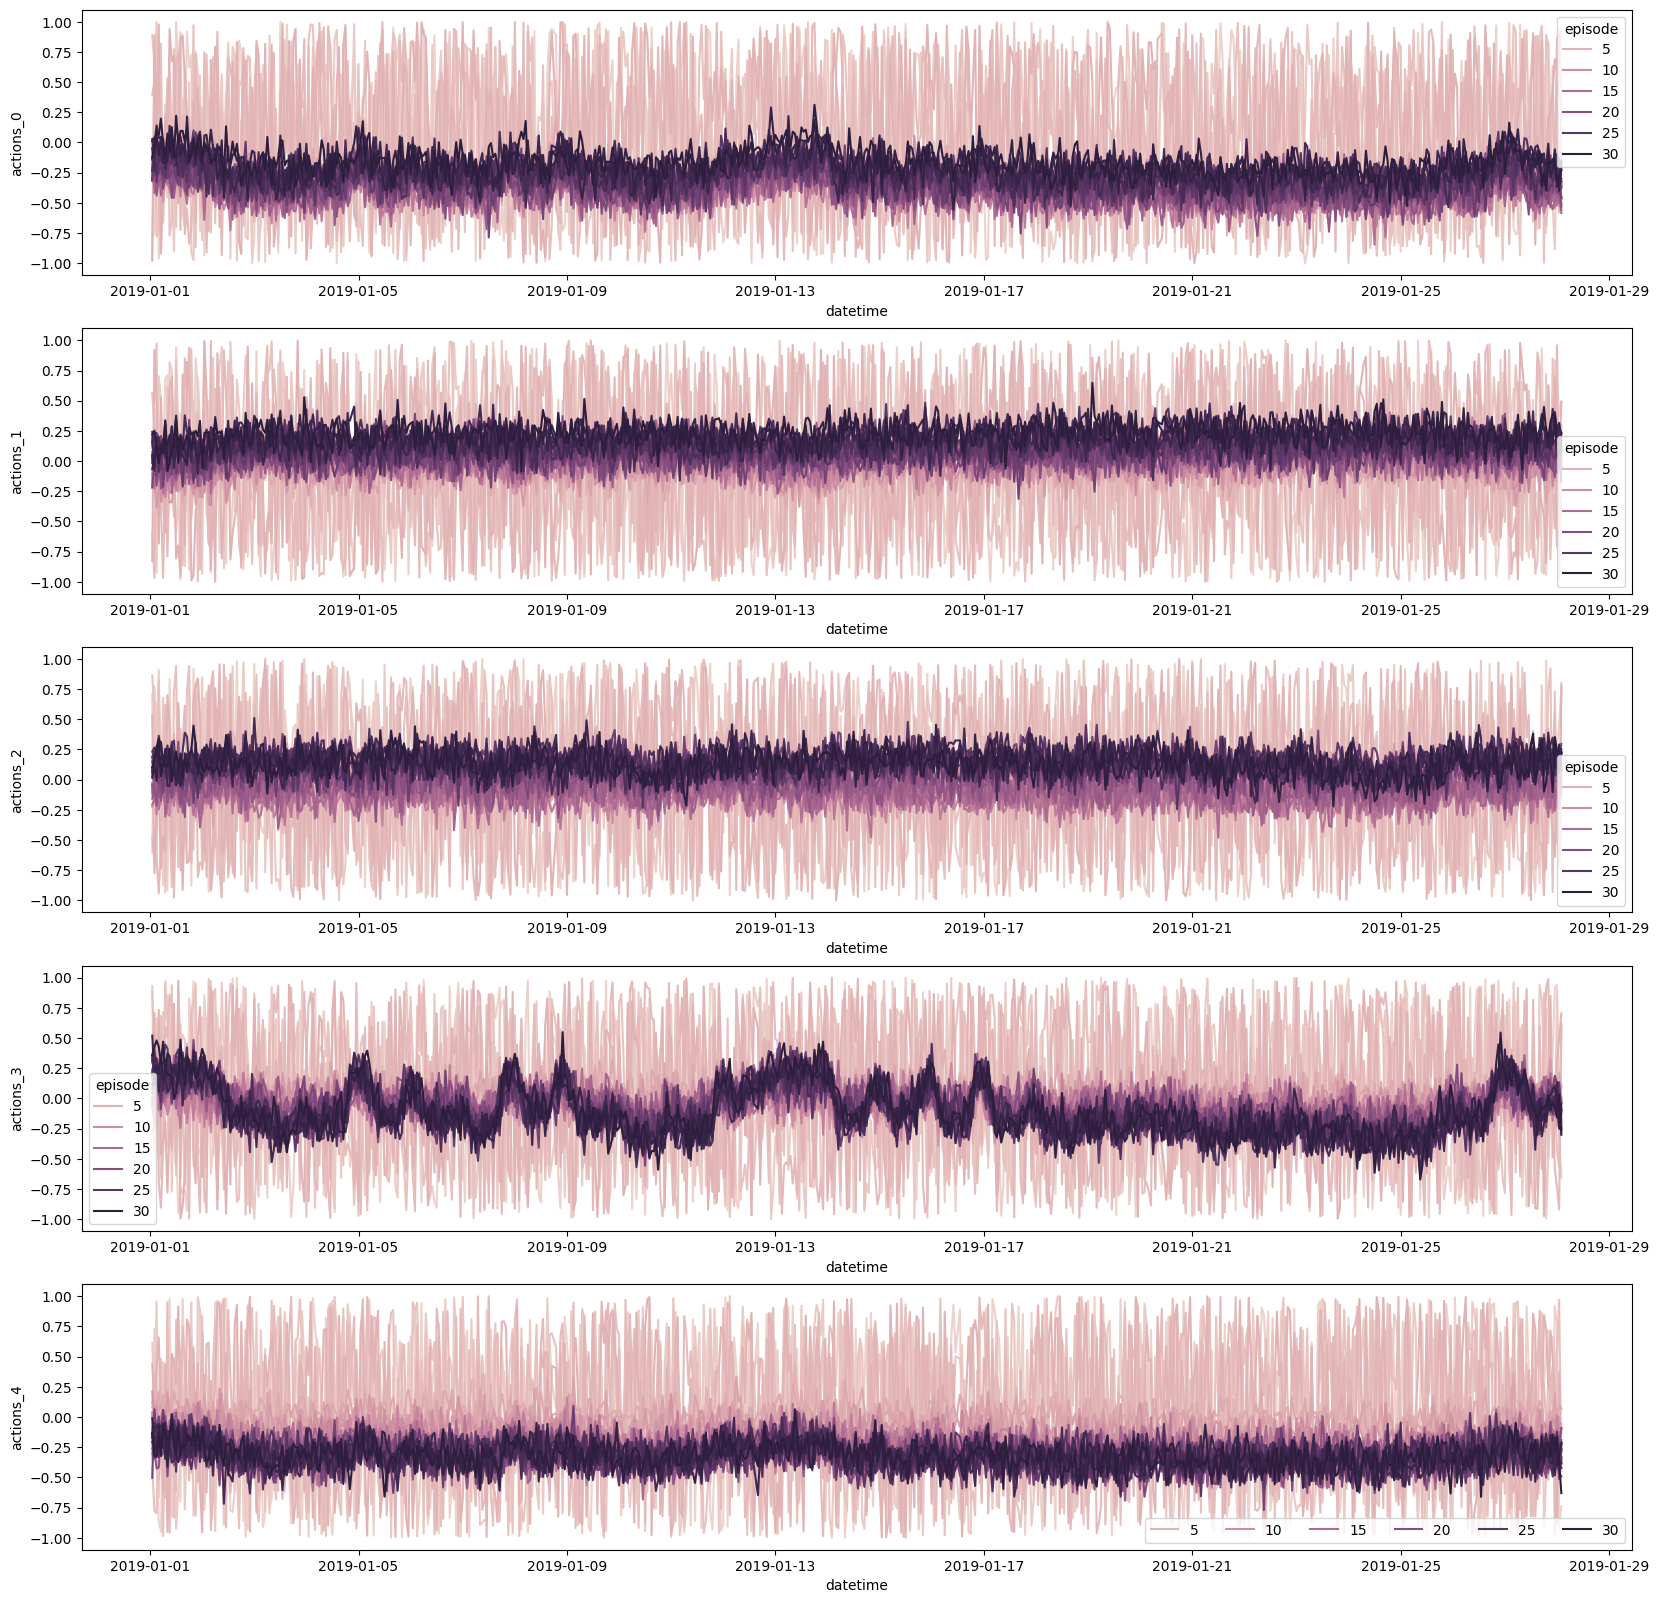

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(5, figsize=(20,20))
cols = [(i/24,1-i/24,1) for i in range(5)]
plot_df = profit_dfs["operator"][profit_dfs["operator"]["eval"] == 0]

for i, ax in enumerate(axes):
    sns.lineplot(data=plot_df, ax=ax, x="datetime", y=f"actions_{i}", hue="episode", errorbar='sd')


ax.legend(ncols=6)

**Plotting the average reward & profit by episode**

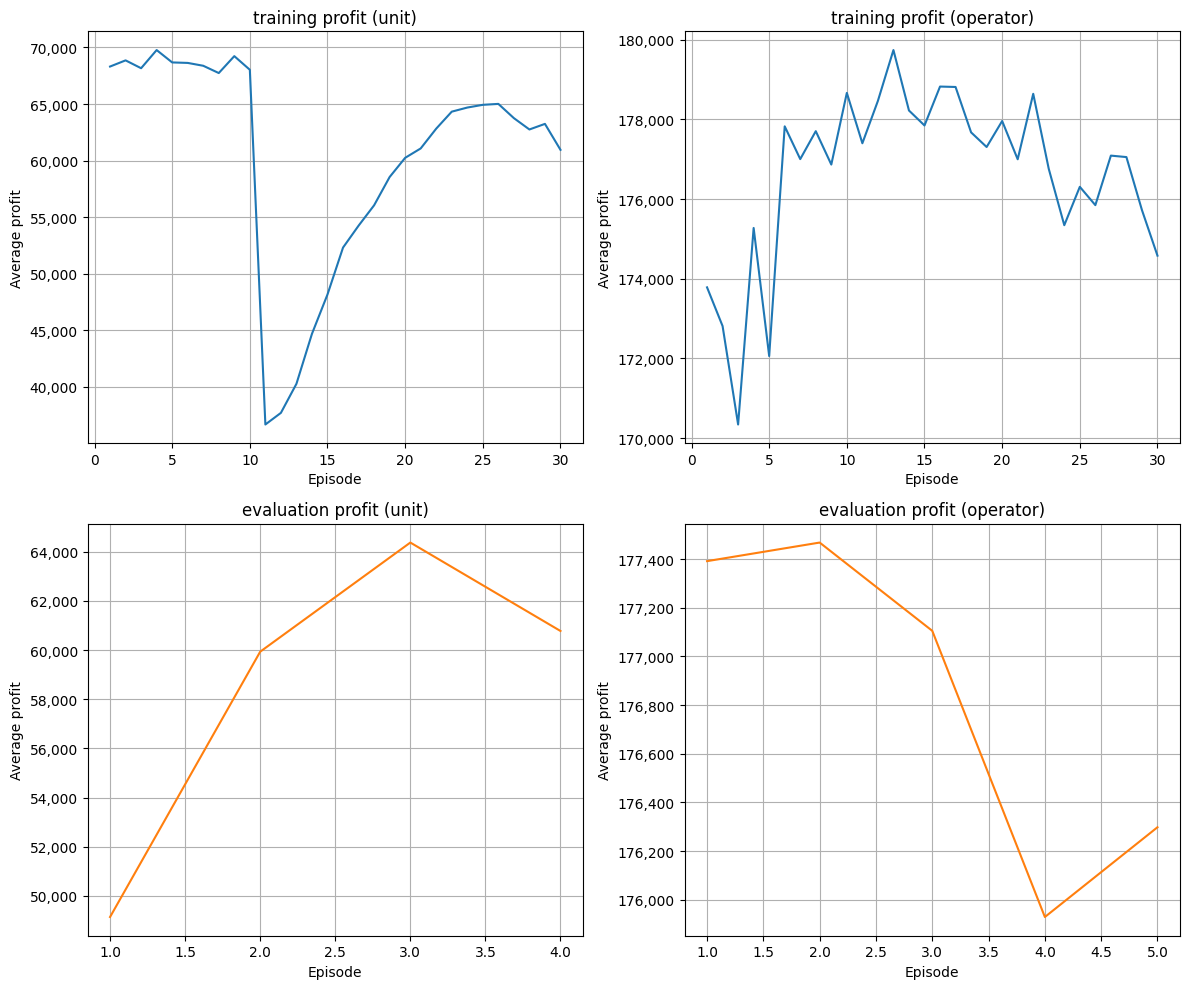

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def comma_formatter(x, pos):
    return f"{x:,.0f}"

# --- Separate plots for training and evaluation ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10),tight_layout=True)
colors = ["tab:blue", "tab:orange"]

for j, key in zip([0,1], ["unit", "operator"]):
  for i, mode in enumerate(["training", "evaluation"]):
    
    plot_df = profit_dfs[key].reset_index()
    # training on the left, evaluation on the right
    plot_df = plot_df[plot_df["eval"] == i]
    # average profit over episode and bidders
    # each date of an episode one row, each bidder reward one col
    pivot_df = plot_df.pivot(values="profit", 
                            columns="unit", 
                            index=["datetime", "episode"])
    # compute total profit of RL agents for that episode & date                               
    tot_profit = pivot_df.sum(axis=1)
    # average of total profit for the same date
    avg_profit = tot_profit.groupby("episode").mean()

    axes[i,j].plot(avg_profit.index, avg_profit.values, color=colors[i])
    axes[i,j].set_title(f"{mode} profit ({key})")
    axes[i,j].set_ylabel("Average profit")
    axes[i,j].set_xlabel("Episode")
    axes[i,j].grid(True)
    axes[i,j].yaxis.set_major_formatter(FuncFormatter(comma_formatter))


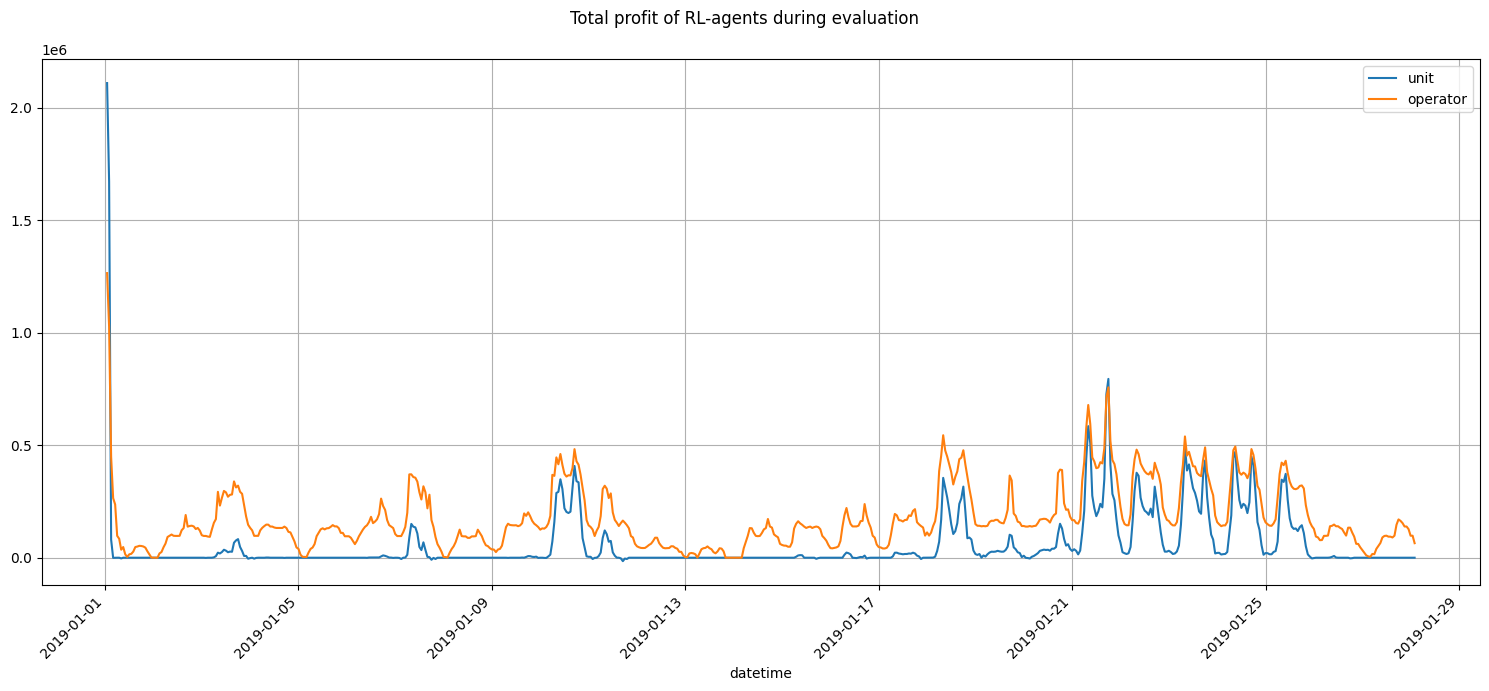

In [28]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(tight_layout=True, figsize=(15,7))

for unit, profit in profit_dfs.items():
    # select profit during evaluation only 
    eval_profit = profit[profit["eval"] == 1].reset_index()
    # each date of an episode one row, each bidder reward one col
    eval_bidder = eval_profit.pivot(values="profit", 
                                    columns="unit", 
                                    index=["datetime", "episode"])
    # compute total profit of RL agents for that episode & date                               
    eval_tot = eval_bidder.sum(axis=1)
    # average of total profit for the same date
    profit_by_date = eval_tot.groupby("datetime").mean()
    profit_by_date.plot(ax=ax, label=unit)

fig.suptitle("Total profit of RL-agents during evaluation")
plt.xticks(rotation=45)
ax.legend()
ax.grid(True)


**Plotting the actions by episode and date**

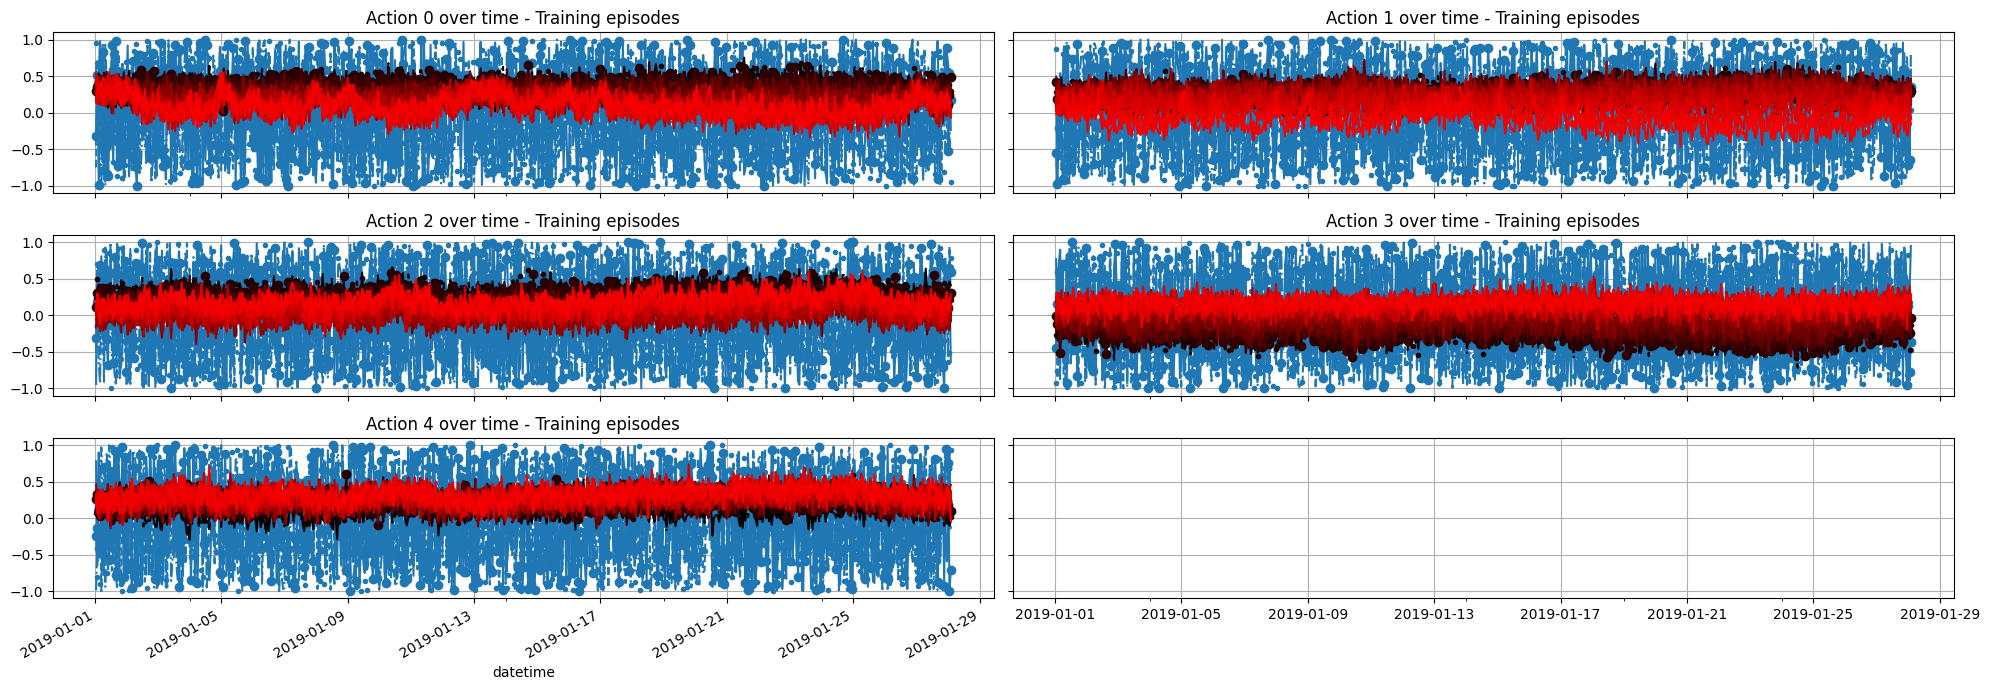

In [8]:
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams['axes.grid'] = True

fig, axes = plt.subplots(3,2, figsize=(20, 7),tight_layout=True, sharex=True, sharey=True)
res_df =  profit_dfs["operator"]
train_df = res_df[res_df["eval"] == 0]
eval_df = res_df[res_df["eval"] == 1]

init_exp_len = op_world.learning_config.episodes_collecting_initial_experience
train_len = op_world.learning_config.training_episodes - init_exp_len
for i in range(5):
    ax = axes.flatten()[i]
    ax.set_title(f"Action {i} over time - Training episodes")
    action = train_df.pivot(index="datetime", columns="episode", values=f"actions_{i}")
    #action = action.resample("1d").mean() # this has the effect of evening out daily patterns
    action.plot(ax=ax, 
                color=["tab:blue"] * init_exp_len + [(i/train_len,0,0) for i in range(train_len)],
                style= ["-","--","-.",".","-o"] * 2,
                legend=False)

**Compute reward and RSI in final simulation**

In [ ]:
import os, sys
from IPython.display import Markdown, display
from util_funcs.db_read import *
from util_funcs.market_power_index import *

inputs_path = "inputs"
names = "competitive", "flexible"#, "unit", "operator"
examples = "germany_mc", "germany_flex"#, "germany_un", "germany_op"

bids_dfs = {}
running_profit_dfs = {}
startup_costs = {}
rsi_dfs = {}
li_dfs = {}
ms_dfs = {}
gap_dfs = {}

#STARTUP_DICT = {u_id: unit.warm_start_cost for u_id, unit in op_world.unit_operators["Operator-RL"].units.items()}


# def startup_fn(df):
#     # TODO: correct function
#     df = df.copy()
#     df = df.sort_values(by=["unit", "datetime"])
#     df["startup"] = (df["power"] > 0).diff()
#     df["startup_cost"] = df["startup"] * df["warm_start_cost"]
#     startup_costs = df.groupby("datetime")["startup_cost"].sum()
#     return startup_costs


for name, example in zip(names, examples):
    if name == "flexible":
        df = read_market_orders(example, simulation_id="germany_mc_base_case_2019")

    else:
        df = read_market_orders(example, study_case="base_case_2019")
    #df["warm_start_cost"] = df["unit"].map(STARTUP_DICT)
    bids_dfs[name] = df[df["unit_operator"] ==  "Operator-RL"]
    profits = df.groupby(["datetime", "unit_operator"])["profit"].sum().unstack()
    running_profit_dfs[name] = profits["Operator-RL"]          
    #startup_costs[name] = startup_fn(df)
    # compute total profit of RL agents for that episode & date                        
    rsi_dfs[name] = residual_supply_index(df)["Operator-RL"]
    li_dfs[name] = lerner_index(df)["Operator-RL"]    
    ms_dfs[name] = marginal_share(df)["Operator-RL"]
    gap_dfs[name] = output_gap(df)["Operator-RL"]
    print(name, "processed.")

import numpy as np


template = (
    "| Model | " + " | ".join(name.title() for name in names) + " |\n"
    "|--------|" + "--------|" * len(names) + "\n"
    "| Total profit (Mn €)  | " + " | ".join(f'{running_profit_dfs[name].sum() / 10**6:,.4f}' for name in names) + " |\n"
    "| Total dispatch (TWh) | " + " | ".join(f'{bids_dfs[name]["power"].sum() / 10**6:,.4f}' for name in names) + " |\n"
    "| RSI corr             | " + " | ".join(f'{running_profit_dfs[name].corr(rsi_dfs[name]):.2f}' for name in names) + " |\n"
    "| Average LI           | " + " | ".join(f'{li_dfs[name].mean():.2f}'  for name in names) + " |\n"
    "| (std)                | " + " | ".join(f'{li_dfs[name].std():.2f}'  for name in names) + " |\n"
    "| Marginal (% of hours)| " + " | ".join(f'{ms_dfs[name]:.2f}'  for name in names) + " |\n"
    "| Output gap           | " + " | ".join(f'{gap_dfs[name].mean():.2%}'  for name in names) + " |\n"
    "| (std)                | " + " | ".join(f'{gap_dfs[name].std():.2%}'  for name in names) + " |\n"
    

)



display(Markdown(template))


| Model | Base | Flexible |
|--------|--------|--------|
| Total profit (Mn €)  | 189.0324 | 185.5331 |
| Total dispatch (TWh) | 10.4702 | 21.5631 |
| RSI corr             | -0.74 | -0.75 |
| Average LI           | 0.00 | -0.02 |
| (std)                | 0.00 | 0.05 |
| Marginal (% of hours)| 0.20 | 0.20 |
| Output gap           | 0.03% | 0.01% |
| (std)                | 0.01% | 0.00% |


In [6]:
from util_funcs.db_read import * 

results = pd.DataFrame()
price_dfs = {}

for name, example in zip(names, examples):
    price_dfs[name] = read_market_price(example, study_case="base_case_2019", inputs_path = "inputs")

y = price_dfs["operator"]["day_ahead_DE_LU"]

metrics = {"MAE": lambda y,y_hat: (y - y_hat).abs(),
           "MSE": lambda y,y_hat: (y - y_hat)**2,
           "MAD": lambda y,y_hat: y - y_hat}

for met in metrics: 
    for example, price_df in price_dfs.items():
        res = metrics[met](y, price_df["price"]).mean()
        results.loc[met, example] = res


results.round(3)

,base,unit,operator
MAE,16.069,8.983,10.906
MSE,516.723,285.048,245.803
MAD,10.468,-3.100,5.302


**Plotting bids**

ValueError: Axis limits cannot be NaN or Inf

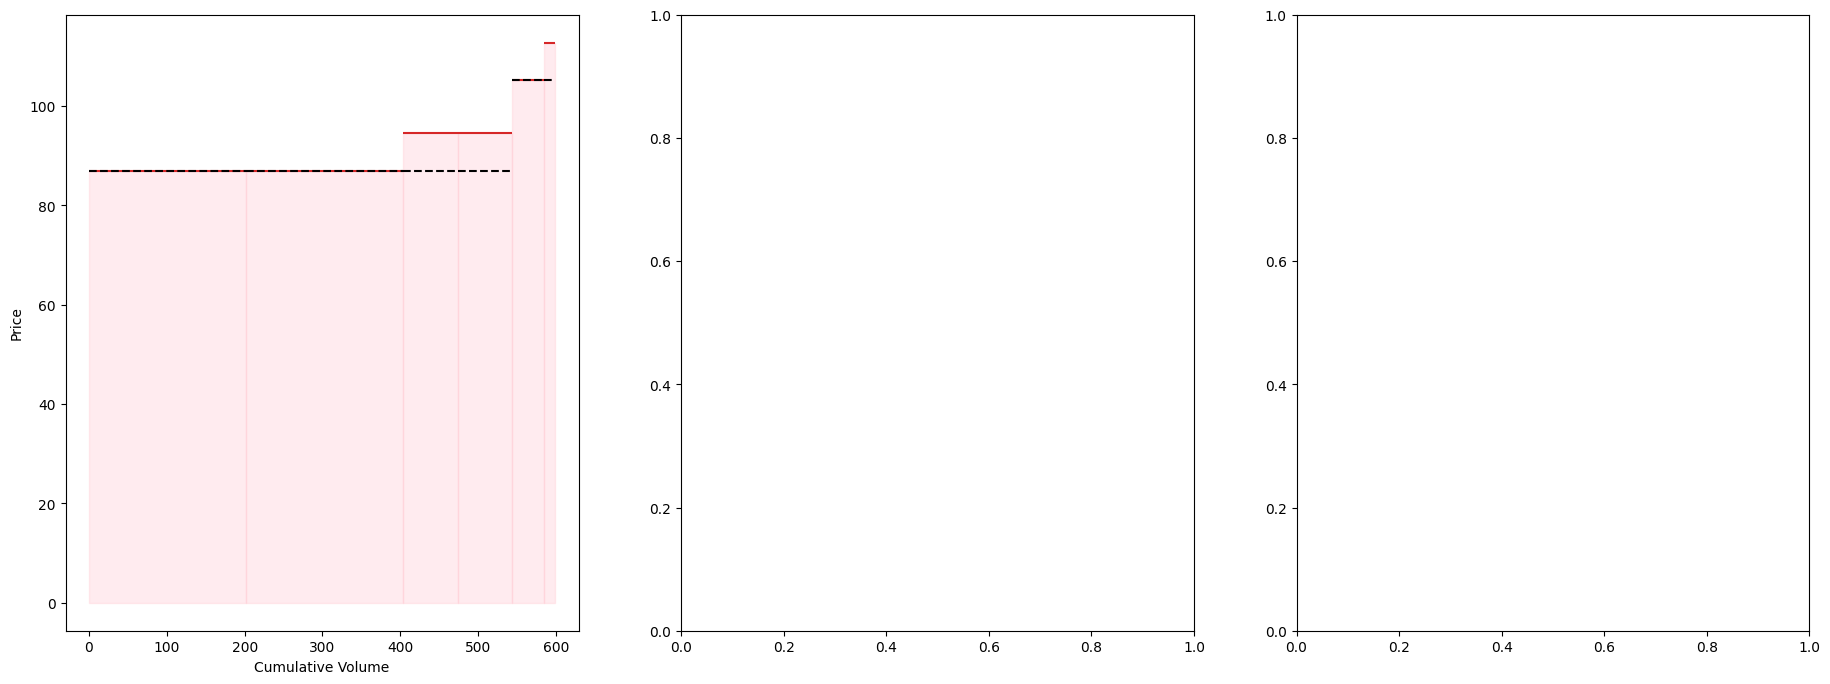

In [29]:
from util_funcs.db_plot import * 

plot_supply_curves(bids_dfs, only_operators=["Operator-RL"])

This concludes our tutorial. By following these steps, you have successfully created a RL Portfolio Strategy and integrated it into the ASSUME framework.